# Machine learning approach 

During this notebook, we are testing different ML algorithms to tackle hypoglycemia prediction problem  

Create our own class to compare different models against several horizons and metrics

In [1]:
import os 
import pandas as pd 
import numpy as np 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [3]:
class Models_Horizon():
    def __init__(self, cut_point:int, test_size:float , window_size:int, horizon:int, folds:int, models:list, model_names:list, metrics:list):
        self.cut_point = cut_point
        self.test_size = test_size
        self.window_size = window_size
        self.horizon = horizon
        self.folds = folds
        self.models = models
        self.model_names = model_names
        self.metrics = metrics


        self.patients = self.load_patients()
        self.results = None
    
    def load_patients(self):
        data_dir = '../Data/Preprocessed'
        base_paths = os.listdir(data_dir)
        full_paths = [os.path.join(data_dir, p) for p in base_paths]
        patients = {}
        spliter = TimeSeriesSplit(n_splits=self.folds, test_size=288) ## We test using one day
        for i, fp in enumerate(full_paths):
            key = base_paths[i].split('.')[0]
            patients[key] = []
            data = pd.read_csv(fp, sep=';')[:self.cut_point]['glucose']
            for k_fold in spliter.split(data):
                k_train = data[k_fold[0]]
                k_test = data[k_fold[1]]
                proper_ml_train_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_train, window_size=self.window_size, horizon=self.horizon)
                proper_ml_test_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_test, window_size=self.window_size, horizon=self.horizon)
                patients[key].append((proper_ml_train_k_fold.generated_data_set, proper_ml_test_k_fold.generated_data_set))
        return patients
    
    def test_models(self):
        keys = list(self.patients.keys())
        results = []
        for key in keys:
            data_folds = self.patients[key] ## A list of tuples 
            columns = data_folds[0][0].columns ## Just to extract columns
            tensor_results_metrics = np.zeros(shape=(len(self.model_names), len(self.metrics), self.folds)) ## 3 cause, we're measuring MSE,MAE and MAPE

            for k, fold in enumerate(data_folds):
                train_k, test_k = fold[0], fold[1]
                X_train_k, y_train_k = train_k[columns[:-1]], train_k[columns[-1]]
                X_test_k, y_test_k = test_k[columns[:-1]], test_k[columns[-1]]
                for m, model in enumerate(self.models):
                    model = clone(model)
                    model.fit(X_train_k, y_train_k)
                    y_pred_k = model.predict(X_test_k)
                    for z, metric in enumerate(self.metrics):
                        result_metric = metric(y_true=y_test_k, y_pred=y_pred_k)
                        tensor_results_metrics[m][z][k] = result_metric
                        
            mse_all_models = tensor_results_metrics[:, 0, :]
            mae_all_models = tensor_results_metrics[:, 1, :]
            mape_all_models = tensor_results_metrics[:, 2, :]

            results.append(list(np.mean(mse_all_models, axis=1)) + list(np.mean(mae_all_models, axis=1)) + list(np.mean(mape_all_models, axis=1)))

        ### Prepare and return a df 
        metrics = ['mse', 'mae', 'mape']
        col_index = pd.MultiIndex.from_product([metrics, self.model_names], names=['metric', 'model'])
        df_final = pd.DataFrame(
            results,
            index=keys,
            columns=col_index
        )
        self.results = df_final
        return df_final

    def visualize_model_comparison(self, figsize=(15, 7)):
        if self.results is None:
            raise ValueError("No results to visualize. Run 'test_models()' first.")
    

        metrics = ['mse', 'mae', 'mape']
        model_names = self.model_names

        _, axes = plt.subplots(1, 3, figsize=figsize)
        colors = ['steelblue', 'seagreen', 'tomato']

        for ax, metric, color in zip(axes, metrics, colors):

            data_plot = self.results[metric]  

            data_long = data_plot.reset_index().melt(
                id_vars='index',
                var_name='Model',
                value_name=metric.upper()
            )
            data_long['Model'] = pd.Categorical(data_long['Model'], categories=model_names)

    
            sns.boxplot(
                data=data_long,
                x='Model',
                y=metric.upper(),
                ax=ax,
                color=color,
                width=0.6
            )

            ax.set_title(f'{metric.upper()}: Window_size:{self.window_size}, Horizon:{self.horizon}')
            ax.set_xlabel('Modelo')
            ax.set_ylabel(metric.upper())
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        
        ## Visualize a summary for each metric
        for m in metrics:
            print(f'{m.upper()}')
            print(self.results[m].describe())
        

## Test it using random forest regressor and gradient boost regressor 

In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler


In [5]:
cut_point = 2290
test_size = 0.2
window_size = 6
horizon = 3
folds = 5
models = [
    RandomForestRegressor(
        n_estimators=100,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ),
    XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          
        min_child_weight=10,  
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ),
    Pipeline(steps=[('scaler', MinMaxScaler(feature_range=(0,1))), ('model', LinearRegression())]),
    Pipeline(steps=[
        ('scaler', MinMaxScaler(feature_range=(0, 1))),
        ('model', RidgeCV(
            alphas=np.logspace(-4, 4, 50),   # ajustable
            cv=None,                         # ← GCV
            store_cv_results=False
        ))
    ]), 
    Pipeline(
    steps=[
        ('scaler', MinMaxScaler(feature_range=(0, 1))),
        ('model', LassoCV(
            alphas=np.linspace(0.01, 1, 50),
            cv=5,
            max_iter=10000
        ))
    ]
    )
]
model_names = ['random_forest', 'gradient_boost', 'xgboost', 'linear_regression', 'ridge_regression', 'lasso_regression']
metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]

In [6]:
horizon_3 = Models_Horizon(
    cut_point=cut_point, 
    test_size=test_size, 
    window_size=window_size, 
    horizon=horizon, 
    folds=folds,
    models=models, 
    model_names=model_names, 
    metrics=metrics
)

In [7]:
results = horizon_3.test_models()

In [8]:
results

metric              mse                                               \
model     random_forest gradient_boost     xgboost linear_regression   
HUPA0004P    294.612656     121.081202  148.604920         55.523421   
HUPA0006P    327.157289     176.042282  209.895852         50.017578   
HUPA0007P    533.347018     386.121210  423.743115        411.876662   
HUPA0009P    121.626213      77.296513   70.410954         15.030784   
HUPA0005P    169.278874     121.489767  139.018882         98.765939   
HUPA0011P    446.516260     281.210951  338.863305        135.823583   
HUPA0003P    221.798014     161.901373  174.796027        132.065859   
HUPA0001P    489.223574     390.728822  395.549119        266.458191   
HUPA0010P    302.083184     195.853767  242.003472         95.921505   
HUPA0002P    148.743149      87.443406  102.275477         38.986920   
HUPA0014P    679.206677     482.190544  534.269735         52.148677   
HUPA0015P    231.423131     121.210925  154.098992         46.236279   
HUPA0016P    207.334946     108.883349  128.166152         59.820836   
HUPA0017P    170.374476     105.084052  126.494419         67.396896   
HUPA0018P    239.276429     109.624955  134.588560         56.615224   
HUPA0021P    242.952204     156.850895  187.186463         73.512327   
HUPA0020P    224.860621     104.760216  124.849210         48.642507   
HUPA0024P    192.473934      88.628896  104.826625         50.823299   
HUPA0019P    370.757590     178.293817  215.526146         92.877304   
HUPA0023P    223.185749     148.137199  165.564195         52.553932   
HUPA0022P    139.950587     132.556098  135.845902        123.785950   
HUPA0025P    136.604833     105.038625  113.759561         45.475262   
HUPA0028P    199.967215     141.200754  166.397838         73.783178   
HUPA0026P    213.001678     108.870208  128.705747         65.584740   
HUPA0027P    113.640805      83.937414   97.754440         55.570567   

metric                                                mae                 \
model     ridge_regression lasso_regression random_forest gradient_boost   
HUPA0004P        55.538528        64.934528     13.185878       8.236273   
HUPA0006P        50.061288        56.550948     13.183147       9.384860   
HUPA0007P       441.021823       435.272837     16.582783      13.350383   
HUPA0009P        15.409559        14.966948      7.171210       4.392699   
HUPA0005P        99.734268       101.446706      9.834064       8.116801   
HUPA0011P       136.528523       138.567397     14.024489      11.291502   
HUPA0003P       132.283527       131.391188     11.159665       8.740454   
HUPA0001P       266.334070       264.863563     15.655150      12.940827   
HUPA0010P        99.093445       101.793628     10.720418       6.898563   
HUPA0002P        39.013638        44.091208      8.899506       6.750204   
HUPA0014P        52.230831        56.023321     13.144383       9.596125   
HUPA0015P        46.354452        55.459480     10.965510       7.983907   
HUPA0016P        59.835848        66.989113     10.555770       7.624107   
HUPA0017P        67.309538        71.996995      9.846558       7.546684   
HUPA0018P        56.633860        62.022704     11.724971       7.387195   
HUPA0021P        73.526031        78.782857     11.121284       8.697528   
HUPA0020P        48.684027        57.537390     11.817265       7.774312   
HUPA0024P        50.816001        61.073311     10.456800       6.999710   
HUPA0019P        92.969636        98.330590     13.949190       9.340043   
HUPA0023P        52.559678        57.328391     10.202276       7.629654   
HUPA0022P       124.738086       124.187167      8.026791       7.848117   
HUPA0025P        45.512348        48.992005      8.159067       6.600666   
HUPA0028P        73.809315        76.520902      9.571069       7.641994   
HUPA0026P        65.666656        74.077780     11.238794       7.328719   
HUPA0027P        55.604425        59.657019      8.142737       6.713536   

me

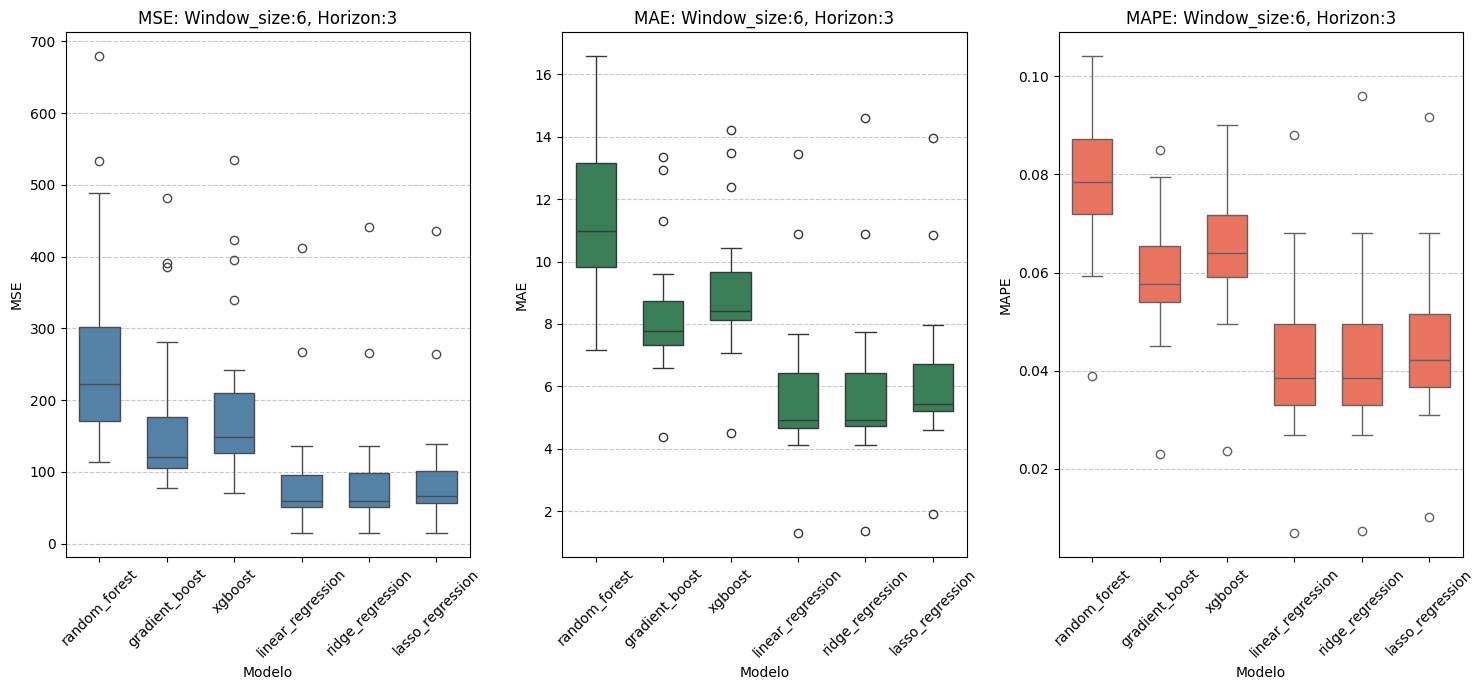

MSE
model  random_forest  gradient_boost     xgboost  linear_regression  \
count      25.000000       25.000000   25.000000          25.000000   
mean      265.575884      166.977490  190.527804          90.611897   
std       140.584159      105.894088  114.335466          83.092349   
min       113.640805       77.296513   70.410954          15.030784   
25%       170.374476      105.084052  126.494419          50.823299   
50%       223.185749      121.489767  148.604920          59.820836   
75%       302.083184      176.042282  209.895852          95.921505   
max       679.206677      482.190544  534.269735         411.876662   

model  ridge_regression  lasso_regression  
count         25.000000         25.000000  
mean          92.050776         96.114319  
std           87.867850         85.153332  
min           15.409559         14.966948  
25%           50.816001         57.328391  
50%           59.835848         66.989113  
75%           99.093445        101.446706  
max 

In [9]:
horizon_3.visualize_model_comparison()

In [10]:
horizon_6 = Models_Horizon(
    cut_point=cut_point, 
    test_size=test_size, 
    window_size=window_size, 
    horizon=6, 
    folds=folds,
    models=models, 
    model_names=model_names, 
    metrics=metrics
)

/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.844e+02, tolerance: 4.219e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.956e+02, tolerance: 3.389e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation

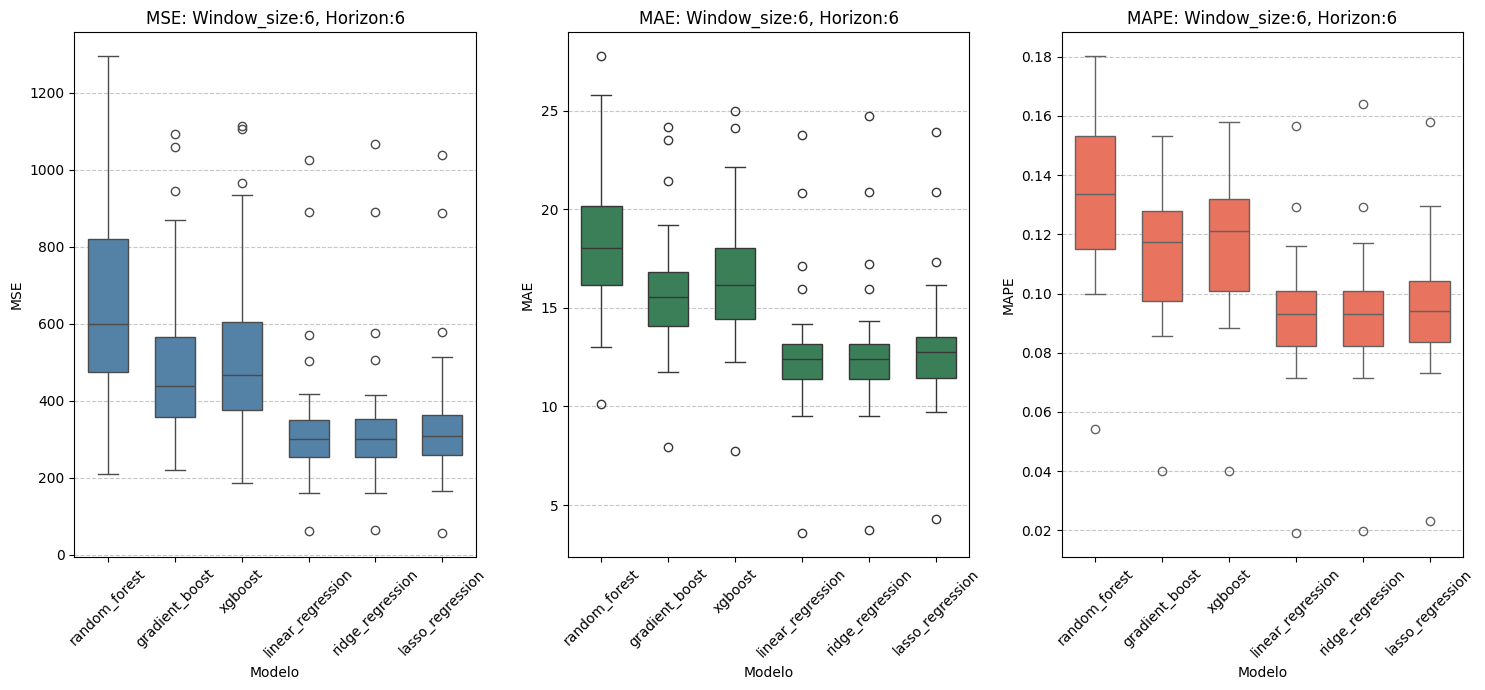

MSE
model  random_forest  gradient_boost      xgboost  linear_regression  \
count      25.000000       25.000000    25.000000          25.000000   
mean      654.952338      516.276795   546.256081         351.810833   
std       298.980813      244.740549   255.573136         210.151150   
min       210.556321      220.828381   185.746547          63.172596   
25%       474.469511      358.160958   377.467062         254.554131   
50%       599.597948      439.887824   467.770421         301.788630   
75%       820.230737      565.616184   604.110649         351.756402   
max      1295.452377     1093.971139  1114.486599        1027.038549   

model  ridge_regression  lasso_regression  
count         25.000000         25.000000  
mean         353.916259        357.919745  
std          215.578626        210.827345  
min           64.931557         57.016596  
25%          254.802823        260.877731  
50%          302.064490        308.577878  
75%          351.897639        363.3651

In [11]:
horizon_6.test_models()
horizon_6.visualize_model_comparison()

In [12]:
horizon_12 = Models_Horizon(
    cut_point=cut_point, 
    test_size=test_size, 
    window_size=window_size, 
    horizon=12, 
    folds=folds,
    models=models, 
    model_names=model_names, 
    metrics=metrics
)

/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.917e+03, tolerance: 4.218e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.173e+02, tolerance: 3.229e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation

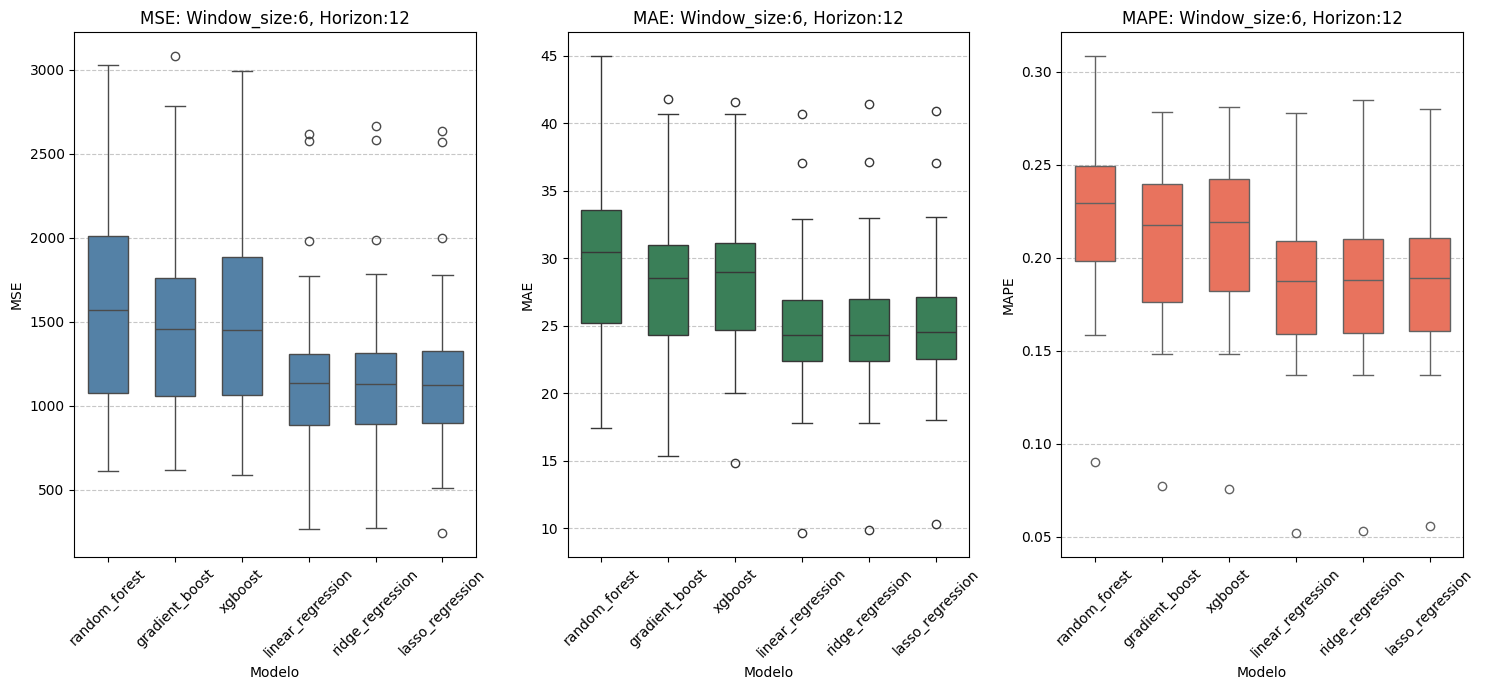

MSE
model  random_forest  gradient_boost      xgboost  linear_regression  \
count      25.000000       25.000000    25.000000          25.000000   
mean     1599.073408     1484.033954  1501.481772        1175.955365   
std       708.248983      634.712509   643.553697         572.806769   
min       610.137935      616.900864   583.778621         263.673700   
25%      1075.715697     1054.847232  1062.456889         886.367966   
50%      1571.748550     1453.230722  1452.748740        1134.333488   
75%      2012.602782     1761.132461  1883.210427        1307.952104   
max      3028.766084     3081.311260  2993.673277        2618.344802   

model  ridge_regression  lasso_regression  
count         25.000000         25.000000  
mean        1179.686466       1182.480942  
std          578.987139        577.015813  
min          268.563773        241.034124  
25%          887.808912        893.411060  
50%         1127.864140       1123.157052  
75%         1311.816278       1327.1150

In [13]:
horizon_12.test_models()
horizon_12.visualize_model_comparison()